# PROJETO 2 - Manutenção Preditiva Industrial
## 1.1 Contextualização
A manutenção preditiva é uma estratégia utilizada na indústria para prever possíveis falhas em máquinas e equipamentos antes que elas aconteçam. Essa abordagem utiliza dados coletados por sensores e sistemas de monitoramento para identificar padrões que indiquem desgaste ou risco de falha.

Sua importância está relacionada à redução de custos com manutenção corretiva, diminuição do tempo de parada das máquinas e aumento da eficiência operacional. O dataset utilizado neste projeto representa informações de funcionamento de máquinas industriais, contendo variáveis relacionadas ao desempenho, temperatura, desgaste e falhas dos equipamentos.

## 1.2 Objetivo
*É possível prever se uma máquina irá falhar com base nas suas condições operacionais?*

O objetivo deste projeto é analisar os dados de manutenção preditiva e identificar padrões associados às falhas das máquinas. Busca-se compreender quais variáveis possuem maior relação com a ocorrência de falhas e como essas informações podem auxiliar na prevenção de problemas industriais.

## 1.3 Descrição dos Dados

O dataset utilizado contém informações sobre o funcionamento de máquinas industriais utilizadas em um ambiente de produção. Os dados incluem variáveis operacionais, condições de temperatura, velocidade de rotação e indicadores de falha.

### Fonte dos Dados

O conjunto de dados foi obtido de uma base pública voltada para estudos de manutenção preditiva e análise de falhas em equipamentos industriais.

Referência: S. Matzka, "Explainable Artificial Intelligence for Predictive Maintenance Applications," AI4I 2020.

### Dicionário das Variáveis

| Coluna | Descrição |
|---|---|
| UDI | Identificador único de cada registro |
| Product ID | Identificação do produto ou máquina |
| Type | Tipo de máquina ou categoria do equipamento |
| Air temperature [K] | Temperatura do ar em Kelvin |
| Process temperature [K] | Temperatura do processo em Kelvin |
| Rotational speed [rpm] | Velocidade de rotação em rotações por minuto |
| Torque [Nm] | Torque aplicado na máquina em Newton-metro |
| Tool wear [min] | Tempo de desgaste da ferramenta em minutos |
| Machine failure | Indica se ocorreu falha geral na máquina |
| TWF | Falha por desgaste da ferramenta |
| HDF | Falha por dissipação de calor |
| PWF | Falha por potência |
| OSF | Falha por sobrecarga |
| RNF | Falha aleatória |



## Seção 2 — Análise Exploratória de Dados
### 2.1 Carregamento e Limpeza dos Dados

In [17]:
df <- read.csv("ai4i2020.csv")

str(df)

summary(df)


'data.frame':	10000 obs. of  14 variables:
 $ UDI                    : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Product.ID             : chr  "M14860" "L47181" "L47182" "L47183" ...
 $ Type                   : chr  "M" "L" "L" "L" ...
 $ Air.temperature..K.    : num  298 298 298 298 298 ...
 $ Process.temperature..K.: num  309 309 308 309 309 ...
 $ Rotational.speed..rpm. : int  1551 1408 1498 1433 1408 1425 1558 1527 1667 1741 ...
 $ Torque..Nm.            : num  42.8 46.3 49.4 39.5 40 41.9 42.4 40.2 28.6 28 ...
 $ Tool.wear..min.        : int  0 3 5 7 9 11 14 16 18 21 ...
 $ Machine.failure        : int  0 0 0 0 0 0 0 0 0 0 ...
 $ TWF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ HDF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ PWF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ OSF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ RNF                    : int  0 0 0 0 0 0 0 0 0 0 ...


      UDI         Product.ID            Type           Air.temperature..K.
 Min.   :    1   Length:10000       Length:10000       Min.   :295.3      
 1st Qu.: 2501   Class :character   Class :character   1st Qu.:298.3      
 Median : 5000   Mode  :character   Mode  :character   Median :300.1      
 Mean   : 5000                                         Mean   :300.0      
 3rd Qu.: 7500                                         3rd Qu.:301.5      
 Max.   :10000                                         Max.   :304.5      
 Process.temperature..K. Rotational.speed..rpm.  Torque..Nm.    Tool.wear..min.
 Min.   :305.7           Min.   :1168           Min.   : 3.80   Min.   :  0    
 1st Qu.:308.8           1st Qu.:1423           1st Qu.:33.20   1st Qu.: 53    
 Median :310.1           Median :1503           Median :40.10   Median :108    
 Mean   :310.0           Mean   :1539           Mean   :39.99   Mean   :108    
 3rd Qu.:311.1           3rd Qu.:1612           3rd Qu.:46.80   3rd Qu.:162

In [18]:

sum(is.na(df))

[1] 0

Nota-se que o dataset não possui valores nulos, o que facilitou o processo de limpeza.

In [19]:
sum(duplicated(df))

[1] 0

Também não haviam cédulas duplicadas.

In [20]:
df$Type <- as.factor(df$Type)
df$Machine.failure <- as.factor(df$Machine.failure)
str(df)

'data.frame':	10000 obs. of  14 variables:
 $ UDI                    : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Product.ID             : chr  "M14860" "L47181" "L47182" "L47183" ...
 $ Type                   : Factor w/ 3 levels "H","L","M": 3 2 2 2 2 3 2 2 3 3 ...
 $ Air.temperature..K.    : num  298 298 298 298 298 ...
 $ Process.temperature..K.: num  309 309 308 309 309 ...
 $ Rotational.speed..rpm. : int  1551 1408 1498 1433 1408 1425 1558 1527 1667 1741 ...
 $ Torque..Nm.            : num  42.8 46.3 49.4 39.5 40 41.9 42.4 40.2 28.6 28 ...
 $ Tool.wear..min.        : int  0 3 5 7 9 11 14 16 18 21 ...
 $ Machine.failure        : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 1 1 1 ...
 $ TWF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ HDF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ PWF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ OSF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ RNF                    : int  0 0 0 0 0 0 0 0 0 0 ...


Transformamos as colunas "*Type*" e "*Machine.failure*" em fatores para distinguir suas variáveis categóricas das demais variáveis numéricas.

### 2.2 Análise Univariada

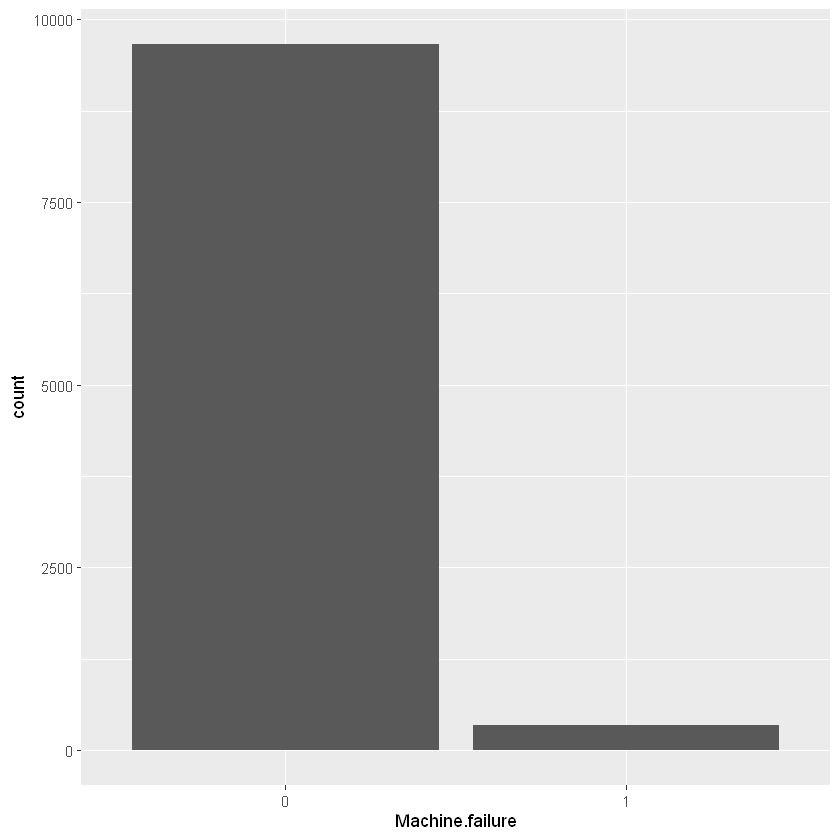

In [27]:
library(ggplot2)

ggplot(data = df, aes(x = Machine.failure)) + geom_bar()